In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import pickle
from tqdm import tqdm

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import (
    Input, Dense, Embedding, Dropout,
    LayerNormalization, MultiHeadAttention
)

from tensorflow.keras.models import Model

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


seed = 42
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "fatemehsariri"
os.environ["KAGGLE_KEY"] = "your token"

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100%|███████████████████████████████████████| 1.04G/1.04G [00:04<00:00, 239MB/s]

Archive:  flickr8k.zip
  inflating: flickr8k/Images/1000268201_693b08cb0e.jpg  
  inflating: flickr8k/Images/1001773457_577c3a7d70.jpg  
  inflating: flickr8k/Images/1002674143_1b742ab4b8.jpg  
  inflating: flickr8k/Images/1003163366_44323f5815.jpg  
  inflating: flickr8k/Images/1007129816_e794419615.jpg  
  inflating: flickr8k/Images/1007320043_627395c3d8.jpg  
  inflating: flickr8k/Images/1009434119_febe49276a.jpg  
  inflating: flickr8k/Images/1012212859_01547e3f17.jpg  
  inflating: flickr8k/Images/1015118661_980735411b.jpg  
  inflating: flickr8k/Images/1015584366_dfcec3c85a.jpg  
  inflating: flickr8k/Images/101654506_8eb26cfb60.jpg  
  inflating: flickr8k/Images/101669240_b2d3e7f17b.jpg  
  inflating: flickr8k/Images/1016887272_03199f49c4.jpg  
  inflating: flickr8k/Images/1019077836_6fc9b15408.jpg  
  inflating: 

In [ ]:
DATA_PATH = "/kaggle/input/datasets/adityajn105/flickr8k"
IMG_PATH = DATA_PATH + "/Images"
CAP_PATH = DATA_PATH + "/captions.txt"

MAX_LENGTH = 40
EMBED_DIM = 256
BATCH_SIZE = 32
df = pd.read_csv(CAP_PATH)
df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [4]:
df = pd.read_csv(CAP_PATH)
df = df[['image', 'caption']]

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    return text.strip()

df['caption'] = df['caption'].apply(clean_text)
df['caption'] = "<start> " + df['caption'] + " <end>"

df.head(10)

,image,caption
0,1000268201_693b08cb0e.jpg,<start> a child in a pink dress is climbing up...
1,1000268201_693b08cb0e.jpg,<start> a girl going into a wooden building <end>
2,1000268201_693b08cb0e.jpg,<start> a little girl climbing into a wooden p...
3,1000268201_693b08cb0e.jpg,<start> a little girl climbing the stairs to h...
4,1000268201_693b08cb0e.jpg,<start> a little girl in a pink dress going in...
5,1001773457_577c3a7d70.jpg,<start> a black dog and a spotted dog are figh...
6,1001773457_577c3a7d70.jpg,<start> a black dog and a tricolored dog playi...
7,1001773457_577c3a7d70.jpg,<start> a black dog and a white dog with brown...
8,1001773457_577c3a7d70.jpg,<start> two dogs of different breeds looking a...
9,1001773457_577c3a7d70.jpg,<start> two dogs on pavement moving toward eac...


In [5]:
image_captions = {}

for img, cap in zip(df['image'], df['caption']):
    image_captions.setdefault(img, []).append(cap)

images = list(image_captions.keys())

In [6]:
cnn = ResNet50(weights="imagenet", include_top=False, pooling="avg")

def extract_features(img_path):
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return cnn.predict(img, verbose=0).flatten()

I0000 00:00:1782863536.408366      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782863536.414599      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
import tensorflow as tf

features = {}

images = os.listdir(IMG_PATH)

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = preprocess_input(img)
    return img

batch_paths = []

for img_name in tqdm(images):

    img_path = os.path.join(IMG_PATH, img_name)
    batch_paths.append((img_path, img_name))

    if len(batch_paths) == 64:

        paths, names = zip(*batch_paths)

        batch_imgs = tf.stack([load_and_preprocess(p) for p in paths])

        feats = cnn.predict(batch_imgs, verbose=0)

        for i, name in enumerate(names):
            features[name] = feats[i]

        batch_paths = []

# last batch
if batch_paths:

    paths, names = zip(*batch_paths)

    batch_imgs = tf.stack([load_and_preprocess(p) for p in paths])

    feats = cnn.predict(batch_imgs, verbose=0)

    for i, name in enumerate(names):
        features[name] = feats[i]

100%|██████████| 8091/8091 [02:31<00:00, 53.28it/s]


In [8]:
import pickle

with open("/kaggle/working/features.pkl", "wb") as f:
    pickle.dump(features, f)

print("Features saved!")
import os

print(os.path.exists("/kaggle/working/features.pkl"))

with open("/kaggle/working/features.pkl", "rb") as f:
    test_features = pickle.load(f)

print(len(test_features))

Features saved!
True
8091


In [9]:
all_captions = [c for caps in image_captions.values() for c in caps]

tokenizer = Tokenizer(filters="")
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1

with open("/kaggle/working/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [10]:
split = int(len(images) * 0.8)
train_imgs = images[:split]
val_imgs = images[split:]

In [11]:
def data_generator(img_list):
    while True:
        X_img, X_seq, y = [], [], []

        for img in img_list:

            if img not in features:
                continue

            for cap in image_captions[img]:

                seq = tokenizer.texts_to_sequences([cap])[0]

                for i in range(1, len(seq)):

                    in_seq = seq[:i]
                    out = seq[i]

                    in_seq = pad_sequences(
                        [in_seq],
                        maxlen=MAX_LENGTH,
                        padding='post'
                    )[0]

                    X_img.append(features[img])
                    X_seq.append(in_seq)
                    y.append(out)

                    if len(X_img) == BATCH_SIZE:
                        yield (
                            (np.array(X_img, dtype=np.float32),
                             np.array(X_seq, dtype=np.int32)),
                            np.array(y, dtype=np.int32)
                        )

                        X_img, X_seq, y = [], [], []

In [12]:
image_input = Input(shape=(2048,))
text_input = Input(shape=(MAX_LENGTH,))


img = Dense(256, activation="relu")(image_input)
img = LayerNormalization()(img)
img = Dropout(0.2)(img)

img = Dense(256)(img)
img = tf.keras.layers.RepeatVector(MAX_LENGTH)(img)

In [13]:
tok = Embedding(vocab_size, EMBED_DIM)(text_input)
tok = tok * tf.math.sqrt(tf.cast(EMBED_DIM, tf.float32))

pos = tf.range(MAX_LENGTH)
pos_emb = Embedding(MAX_LENGTH, EMBED_DIM)(pos)

x = tok + pos_emb
x = Dropout(0.2)(x)

In [14]:
def decoder_block(x, img):

    attn1 = MultiHeadAttention(
        num_heads=4,
        key_dim=64,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    x = LayerNormalization()(x + attn1)

    attn2 = MultiHeadAttention(
        num_heads=4,
        key_dim=64,
        dropout=0.1
    )(x, img)

    x = LayerNormalization()(x + attn2)

    ffn = Dense(1024, activation="gelu")(x)
    ffn = Dropout(0.2)(ffn)
    ffn = Dense(256)(ffn)

    x = LayerNormalization()(x + ffn)

    return x

In [15]:
x = decoder_block(x, img)
x = decoder_block(x, img)
x = decoder_block(x, img)

output = Dense(vocab_size, activation="softmax")(x[:, -1, :])

model = Model([image_input, text_input], output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
def beam_search(image_feature, beam=3):

    start = tokenizer.word_index["<start>"]
    end = tokenizer.word_index["<end>"]

    sequences = [([start], 0.0)]

    for _ in range(MAX_LENGTH):

        all_candidates = []

        for seq, score in sequences:

            padded = pad_sequences(
                [seq],
                maxlen=MAX_LENGTH,
                padding='post'
            )

            preds = model(
                [
                    image_feature.reshape(1,2048),
                    padded
                ],
                training=False
            )

            preds = preds.numpy()[0]

            top_ids = np.argsort(preds)[-beam:]

            for w in top_ids:

                prob = preds[w]

                new_seq = seq + [w]

                new_score = score - np.log(prob + 1e-7)

                all_candidates.append((new_seq, new_score))


        sequences = sorted(all_candidates, key=lambda x: x[1])[:beam]


    best = sequences[0][0]

    caption = []

    for w in best:
        if w == end:
            break
        if w != start:
            caption.append(tokenizer.index_word.get(w, ""))

    return " ".join(caption)

In [17]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm import tqdm


def evaluate_bleu(images, image_captions):

    actual = []
    predicted = []

    for img_name in tqdm(images, desc="BLEU evaluation"):

        if img_name not in features:
            continue

        # generate caption
        pred_caption = beam_search(
            features[img_name],
            beam=3
        )

        predicted.append(
            pred_caption.split()
        )

        # ground truth captions
        refs = [
            cap.split()
            for cap in image_captions[img_name]
        ]

        actual.append(refs)


    smooth = SmoothingFunction().method1

    bleu = corpus_bleu(
        actual,
        predicted,
        smoothing_function=smooth
    )

    return bleu

In [ ]:
class BLEUCallback(tf.keras.callbacks.Callback):

    def __init__(self, val_imgs, val_captions, features):
        super().__init__()
        self.val_imgs = val_imgs
        self.val_captions = val_captions
        self.features = features

    def on_epoch_end(self, epoch, logs=None):

        #  epoch 5 and 10 only
        if (epoch + 1) not in [5, 10]:
            return

        print(f"\n🔥 BLEU Epoch {epoch+1}")

        actual = []
        predicted = []

        sample = self.val_imgs[:50]

        for img in tqdm(sample):

            if img not in self.features:
                continue

            pred = beam_search(self.features[img], 3)

            refs = [c.split() for c in self.val_captions[img]]

            actual.append(refs)
            predicted.append(pred.split())

        smooth = SmoothingFunction().method1

        bleu = corpus_bleu(
            actual,
            predicted,
            smoothing_function=smooth
        )

        print(f"\n✅ BLEU: {bleu:.6f}")

        print("\nSample:")
        test = sample[0]
        print("IMG:", test)
        print("PRED:", beam_search(self.features[test], 3))

In [19]:
import random
import tensorflow as tf

class SampleCaptionCallback(tf.keras.callbacks.Callback):

    def __init__(self, val_imgs, features, image_captions, tokenizer):
        super().__init__()
        self.val_imgs = val_imgs
        self.features = features
        self.image_captions = image_captions
        self.tokenizer = tokenizer


    def on_epoch_end(self, epoch, logs=None):

        img = random.choice(self.val_imgs)

        if img not in self.features:
            print("Image not found in features")
            return

        pred = beam_search(self.features[img], beam=3)

        gt = self.image_captions[img][0]

        print("\n" + "="*50)
        print(f"🔥 Epoch {epoch+1} SAMPLE RESULT")
        print("IMAGE:", img)
        print("GT   :", gt)
        print("PRED :", pred)
        print("="*40 + "\n")

In [20]:
sample_callback = SampleCaptionCallback(
    val_imgs,
    features,
    image_captions,
    tokenizer
)


In [21]:
bleu_callback = BLEUCallback(val_imgs, image_captions, features)

callbacks = [
    bleu_callback,
     sample_callback,

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [22]:
images = list(image_captions.keys())

split = int(len(images) * 0.8)

train_imgs = images[:split]
val_imgs = images[split:]

train_captions = {img: image_captions[img] for img in train_imgs}
val_captions = {img: image_captions[img] for img in val_imgs}

In [23]:
def count_samples(img_dict):

    total = 0

    for img, captions in img_dict.items():

        for cap in captions:

            seq = tokenizer.texts_to_sequences([cap])[0]

            total += len(seq)-1

    return total


train_samples = count_samples(train_captions)
val_samples = count_samples(val_captions)




In [24]:
BATCH_SIZE = 32

steps = train_samples // BATCH_SIZE
val_steps = val_samples // BATCH_SIZE

print(steps)
print(val_steps)

11907
2992


In [25]:
history = model.fit(
    data_generator(train_imgs),
    validation_data=data_generator(val_imgs),
    epochs=10,
    steps_per_epoch=steps,
    validation_steps=val_steps,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
11905/11907 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2272 - loss: 4.7377
🔥 Epoch 1 SAMPLE RESULT
IMAGE: 1550772959_9ca9fa625f.jpg
GT   : <start> a girl sits with excavating tools examining a rock <end>
PRED : a man in a yellow shirt is standing on a tree

11907/11907 ━━━━━━━━━━━━━━━━━━━━ 301s 23ms/step - accuracy: 0.2603 - loss: 4.3447 - val_accuracy: 0.3060 - val_loss: 3.8831
Epoch 2/10
11906/11907 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3109 - loss: 3.7181
🔥 Epoch 2 SAMPLE RESULT
IMAGE: 33108590_d685bfe51c.jpg
GT   : <start> a young couple inspect merchandise from a street vendor <end>
PRED : a group of people are standing in front of a crowd

11907/11907 ━━━━━━━━━━━━━━━━━━━━ 268s 22ms/step - accuracy: 0.3160 - loss: 3.6778 - val_accuracy: 0.3291 - val_loss: 3.6330
Epoch 3/10
11906/11907 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3318 - loss: 3.4792
🔥 Epoch 3 SAMPLE RESULT
IMAGE: 2256218522_53b92bcbb2.jpg
GT   : <start> a black and white dog is running 

100%|██████████| 50/50 [09:27<00:00, 11.35s/it]



✅ BLEU: 0.172668

Sample:
IMG: 2445283938_ff477c7952.jpg
PRED: three young girls are standing in a gym

🔥 Epoch 5 SAMPLE RESULT
IMAGE: 533979933_a95b03323b.jpg
GT   : <start> a boy holding an oar walk through the ocean <end>
PRED : a man is playing in the water

11907/11907 ━━━━━━━━━━━━━━━━━━━━ 847s 71ms/step - accuracy: 0.3573 - loss: 3.2154 - val_accuracy: 0.3502 - val_loss: 3.4274
Epoch 6/10
11905/11907 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3614 - loss: 3.1494
🔥 Epoch 6 SAMPLE RESULT
IMAGE: 3208074567_ac44aeb3f3.jpg
GT   : <start> a boy wearing a red shirt is splashed by water <end>
PRED : a child is in the snow

11907/11907 ━━━━━━━━━━━━━━━━━━━━ 268s 22ms/step - accuracy: 0.3630 - loss: 3.1413 - val_accuracy: 0.3578 - val_loss: 3.3856
Epoch 7/10
11906/11907 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3704 - loss: 3.0655
🔥 Epoch 7 SAMPLE RESULT
IMAGE: 288025239_5e59ba9c3b.jpg
GT   : <start> a man pokes his head out of the red tent in the snow <end>
PRED : a man in a re

100%|██████████| 50/50 [09:25<00:00, 11.31s/it]



✅ BLEU: 0.161050

Sample:
IMG: 2445283938_ff477c7952.jpg
PRED: three young girls are sitting on a bench with a young girl in the background

🔥 Epoch 10 SAMPLE RESULT
IMAGE: 3446191973_1db572ed8a.jpg
GT   : <start> a group of people stand on a stage and hold colorful buckets <end>
PRED : a group of people in colorful outfits are standing in the street

11907/11907 ━━━━━━━━━━━━━━━━━━━━ 845s 71ms/step - accuracy: 0.3842 - loss: 2.9164 - val_accuracy: 0.3655 - val_loss: 3.3515


In [ ]:
model.save("/kaggle/working/model.keras")

In [ ]:
def show_image_with_caption(img_name):
    
    img_path = os.path.join(IMG_PATH, img_name)

    img = load_img(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("\n📌 Ground Truth captions:")
    for c in image_captions[img_name]:
        print("-", c)

    feat = features[img_name]
    caption = beam_search(feat, beam=3)

    print("\n🤖 Predicted Caption:")
    print(caption)

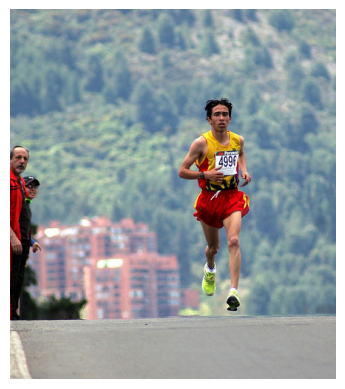


📌 Ground Truth captions:
- <start> a runner in a yellow shirt is cresting a hill <end>
- <start> a runner with one green shoe and one white shoe runs uphill <end>
- <start> a single runner is watched by onlookers in a race <end>
- <start> man wearing green sneakers runs down highway <end>
- <start> the runner in red and yellow has just made it up the hill <end>

🤖 Predicted Caption:
a man in a yellow shirt jumps into the air


In [40]:
show_image_with_caption(random.choice(val_imgs))

In [31]:
def show_image_with_caption(img_name):

    img_path = os.path.join(IMG_PATH, img_name)

    img = load_img(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Image loaded")

    feat = features[img_name]
    print("Feature loaded")

    caption = beam_search(feat, beam=3)
    print("Caption generated")

    print("Prediction:", caption)

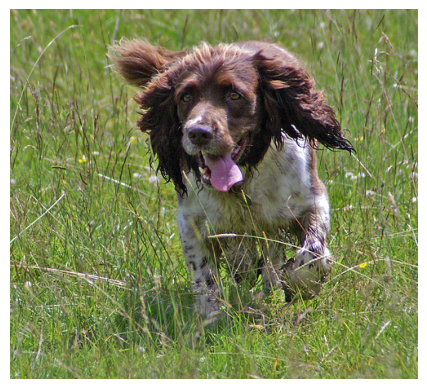

Image loaded
Feature loaded
Caption generated
Prediction: a brown dog runs through the grass


In [33]:
show_image_with_caption(random.choice(val_imgs))

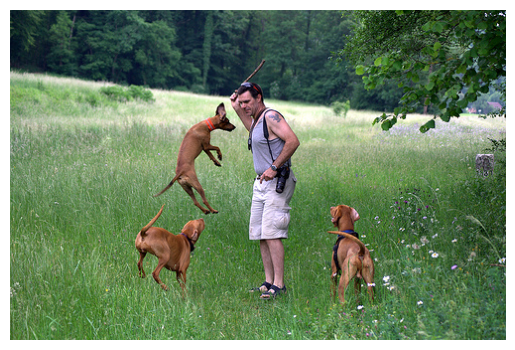

Image loaded
Feature loaded
Caption generated
Prediction: a man and a dog are playing with a brown dog


In [34]:
show_image_with_caption(random.choice(val_imgs))